# Import libs and read synthetic data

In [1]:
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
from Strong_hierarchical_lasso.SHIM import * # our library
from Create_synthetic_datasets import *


# --- Specify number of levels for each factor ---
l1, l2, l3 = 7,6,8
levels_list=[l1,l2,l3]
# Get ranges
ranges = get_ranges3(l1=l1, l2=l2, l3=l3)
range_main, range_2way, range_3way = ranges

data_normal=create_basic_GLM_4way()

X=data_normal["X"]
y=data_normal["y"].obs
beta_true=data_normal["beta"]["coeffs"][1:]
interc_true=data_normal["beta"]["coeffs"][0]

print(X.shape)


beta_true_main=beta_true[range_main]
beta_true_2way=beta_true[range_2way]
beta_true_3way=beta_true[range_3way]


Data loaded properly
(504, 503)


 # Shim with main init 

 Start iteration: 1;
Updated intercept
Updated beta
Updated gamma
Updated delta
 Start iteration: 2;
Updated intercept
Updated beta
Updated gamma
Updated delta
 Start iteration: 3;
Updated intercept
Updated beta
Updated gamma
Updated delta
The model has converged.
R² score: 0.7781238113371075


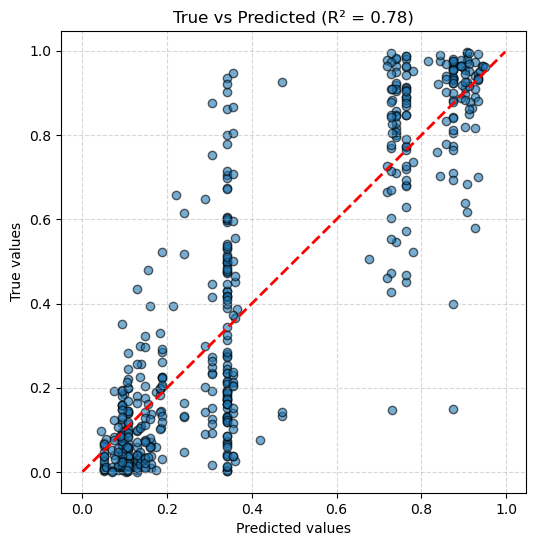

In [2]:
shim = SHIM(X=X,
            y=y,
            init_list=None,
            levels_list=levels_list,
            use_init_main=True, use_init_main_w=True,
            lambdas_list=[3e-3, 7e-4, 1e-1],
            response='cb',
            max_iter=10
        )

shim_fitted = shim.fit_model()
shim_fitted.R2_score(X, y, plot=True)
beta_all_shim=shim_fitted.model.beta_all
intercept_all=shim_fitted.model.intercept
beta_main_shim=beta_all_shim[range_main]
beta_2way_shim=beta_all_shim[range_2way]
beta_3way_shim=beta_all_shim[range_3way]


# Results
# Even if the R^2 score when fitting on entire data is 0.78, our model identifies almost perfectly which coefficients are non-zero and which are not  

In [3]:
print("Main shim:")
print(beta_main_shim)

print("Main true:")
print(beta_true_main.values)

print("Two way shim first 10 coefs:")
print(beta_2way_shim[:10])
print("Two way true first 10 coefs:")
print(beta_true_2way.values[:10])

print("Three way shim first 10 coefs:")
print(beta_3way_shim[:10])
print("Three way true first 10 coefs:")
print(beta_true_3way.values[:10])


import numpy as np

def compute_tpr_fpr(vec_true, vec_pred):
    vec_true = np.array(vec_true)
    vec_pred = np.array(vec_pred)
    
    # True Positives, False Positives, True Negatives, False Negatives
    TP = np.sum((vec_true == 0) & (vec_pred == 0))
    FP = np.sum((vec_true != 0) & (vec_pred == 0))
    TN = np.sum((vec_true !=0) & (vec_pred != 0))
    FN = np.sum((vec_true == 0) & (vec_pred !=0))
    
    # Avoid division by zero
    TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    
    print(f"TPR is {TPR*100:.2f}%")
    print(f"FPR is {FPR*100:.2f}%")
    




print("Results for main:")
compute_tpr_fpr(beta_true_main, beta_main_shim)
print("Results for 2ways:")
compute_tpr_fpr(beta_true_2way, beta_2way_shim)

Main shim:
[-5.66354941  5.44450955  0.          0.          0.          0.
  0.          5.94205743 -8.52954961 -7.32537429  0.          0.
  0.          5.17935968 -4.64557453  0.          0.          0.
  0.          0.          0.        ]
Main true:
[-8.47282891  7.43388122  0.          0.          0.          0.
  0.          5.68943736 -8.67951823 -7.59456498  0.          0.
  0.          6.8055934  -4.84102845  0.          0.          0.
  0.          0.          0.        ]
Two way shim first 10 coefs:
[-4.36551393 -2.86198556 -4.06704858 -0.         -0.         -0.
 -4.6538267   2.08033252 -0.         -0.        ]
Two way true first 10 coefs:
[-3.66655303 -3.21495945 -2.42526761  0.          0.          0.
 -4.87663636  4.95329541  0.          0.        ]
Three way shim first 10 coefs:
[ 0.  0.  0.  0.  0.  0.  0.  0. -0. -0.]
Three way true first 10 coefs:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Results for main:
TPR is 100.00%
FPR is 0.00%
Results for 2ways:
TPR is 93.53%
FPR is 0.

# Recover coefs from last level of each factor  with identifiability conditions

In [4]:


main_names = (
    [f"A.{i}" for i in range(1, 9)] +
    [f"B.{i}" for i in range(1, 8)] +
    [f"C.{i}" for i in range(1, 10)] 
)

recovered_coefs=recover_coefs_with_names(main_names=main_names, beta= beta_all_shim, intercept=intercept_all, levels=levels_list)


print(recovered_coefs)

               Values
intercept   -2.031900
A.1         -5.663549
A.2          5.444510
A.3          0.000000
A.4          0.000000
...               ...
A.8:B.7:C.5 -0.000000
A.8:B.7:C.6 -0.000000
A.8:B.7:C.7 -0.000000
A.8:B.7:C.8 -0.000000
A.8:B.7:C.9 -0.000000

[720 rows x 1 columns]
